In [1]:
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np
import librosa
from glob import glob
from umap import UMAP
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import random 
import math
from tqdm import tqdm
from tensorflow.keras.utils import Sequence

from sklearn.metrics import roc_curve, auc


In [2]:
model = load_model("best")
 

In [3]:
N = 1024  # length of 
 
def getbrokenfile(fnames):
    while True:
        f = random.choice(fnames)
        x = np.load(f)
        if(x.shape[0]==1_000_000):
            return x
        else:
            print("broken")

class MyGenerator(Sequence):
    def __init__(self, fnames, batch_size=64):
        self.fnames = fnames
        self.batch_size= 64
        
    def __len__(self):
        return math.ceil(len(self.fnames) / self.batch_size)
    
    def __getitem__(self, idx):
        x_train = []
        y_train = []
        for i in range(self.batch_size):
            a = getbrokenfile(self.fnames)
            a = (a-a.min())/a.max()
            idx = random.choice(list(range(0, a.shape[0]-N) ))
            aa = a[idx:idx+N]
            b = getbrokenfile(self.fnames)
            b = (b-b.min())/b.max()
 
            idx = random.choice(list(range(0, b.shape[0]-N )))
            bb = b[idx:idx+N]
            
            choice = random.choice([0,1])
            y_train.append(choice)
            idx = random.choice(list(range(0, a.shape[0]-N )))
             
            if(choice==0):
                #source is A
                clip = a[idx:idx+N]
            else:
                clip = b[idx:idx+N]
            assert len(clip)==N
            x_train.append(np.hstack([aa,bb,clip]))
        x_train = np.array(x_train)
        y_train = np.array(y_train)
        return x_train, y_train     
        
fnames = glob("goldclips/*")
random.shuffle(fnames)
mygen = MyGenerator(fnames)
mygen = MyGenerator(glob("clips/test/*npy"))
mygen.__len__()

70

In [8]:
y_test = []
y_hat = []
for i in  range(70):
    print(i)
    x,y = mygen.__getitem__(i)
    ytmp = model.predict(x)
    y_test.append(y)
    y_hat.append(ytmp)

2/2 [==============================] - 0s 2ms/step


Text(0.5, 1.0, 'AUC: 0.998')

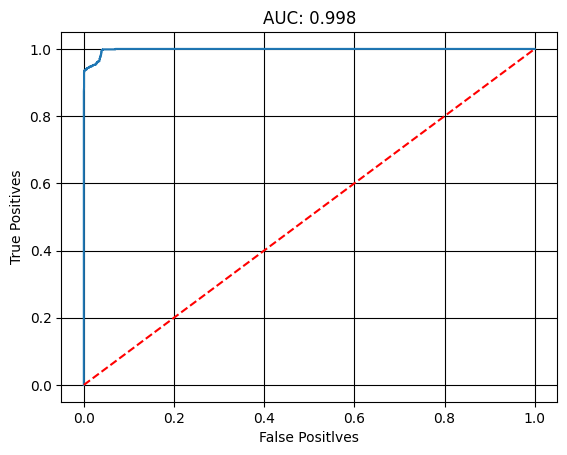

In [9]:
y_test = np.hstack(y_test)
y_hat = np.vstack (y_hat)

fp,tp, th = roc_curve(y_test, y_hat)
plt.plot(fp,tp)
plt.plot([0,1],[0,1], linestyle='--',c='r')
plt.grid( which='major', linestyle='-',c='k')
plt.grid( which='minor', linestyle='--',c='r')
 
plt.xlabel("False Positlves")
plt.ylabel("True Positives")
plt.title(f"AUC: {auc(fp,tp):0.3f}")

Text(0.5, 1.0, 'AUC: 0.911')

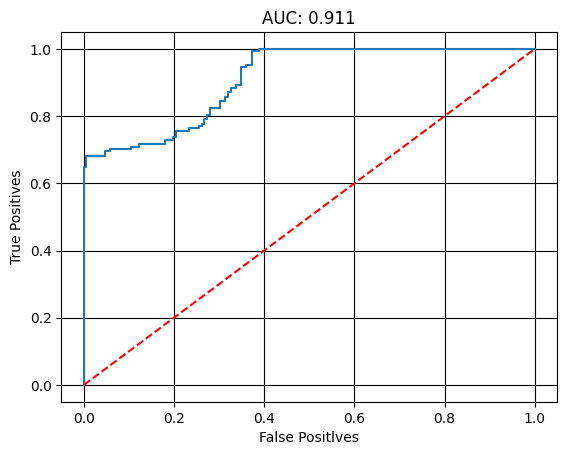

In [14]:
y_test = np.hstack(y_test)
y_hat = np.vstack (y_hat)

fp,tp, th = roc_curve(y_test, y_hat)
plt.plot(fp,tp)
plt.plot([0,1],[0,1], linestyle='--',c='r')
plt.grid( which='major', linestyle='-',c='k')
plt.grid( which='minor', linestyle='--',c='r')
 
plt.xlabel("False Positlves")
plt.ylabel("True Positives")
plt.title(f"AUC: {auc(fp,tp):0.3f}")
 